# Serving for Data Analytics: Local DuckDB Version

In a managed cloud analytics setup, transformed Parquet data might live in Amazon S3 and be queried with Amazon Athena.

In this local lab, the same idea is implemented with MinIO and DuckDB:

```text
MinIO stores Parquet files -> DuckDB queries them -> Jupyter builds charts
```

DuckDB is the local SQL query engine. It does not replace MySQL. MySQL is the operational source database; DuckDB reads the analytical Parquet files produced by the ETL job.


## Star Schema After ETL

The ETL job transforms the normalized operational MySQL tables into analytical tables: dimensions and a fact table.

![Star schema after ETL](schema_after_etl.png)


## Imports

The notebook uses DuckDB for SQL queries, Pandas for DataFrames, Seaborn/Matplotlib for charts, and ipywidgets for interactivity.


In [1]:
import os
import warnings

import duckdb
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")


## Configure DuckDB for MinIO

When running Jupyter directly on your Mac, use `localhost:9000`.

When running Jupyter from `dashboard/docker-compose.yml`, the notebook container uses `classicmodels-minio:9000` because both containers share the `min_io_default` Docker network.


In [2]:
S3_ENDPOINT = os.getenv("S3_ENDPOINT", "localhost:9000")
S3_BUCKET = os.getenv("S3_BUCKET", "classicmodels")
S3_PREFIX = os.getenv("S3_PREFIX", "warehouse")
AWS_ACCESS_KEY_ID = os.getenv("AWS_ACCESS_KEY_ID", "minioadmin")
AWS_SECRET_ACCESS_KEY = os.getenv("AWS_SECRET_ACCESS_KEY", "minioadmin")

con = duckdb.connect()
con.sql("INSTALL httpfs;")
con.sql("LOAD httpfs;")
con.sql("SET s3_region='us-east-1';")
con.sql(f"SET s3_endpoint='{S3_ENDPOINT}';")
con.sql(f"SET s3_access_key_id='{AWS_ACCESS_KEY_ID}';")
con.sql(f"SET s3_secret_access_key='{AWS_SECRET_ACCESS_KEY}';")
con.sql("SET s3_use_ssl=false;")
con.sql("SET s3_url_style='path';")

base_path = f"s3://{S3_BUCKET}/{S3_PREFIX}"
base_path


's3://classicmodels/warehouse'

## Check the Product Dimension

This is the local equivalent of an Athena query over an analytical table:

```python
wr.athena.read_sql_query("SELECT * FROM dim_products", database=GLUE_DATABASE)
```

Here, DuckDB reads the Parquet file directly from MinIO.


In [3]:
products_df = con.sql(f"""
    SELECT *
    FROM read_parquet('{base_path}/dim_products/*.parquet')
""").df()

products_df.head()


,productCode,productName,productLine,productScale,productVendor,productDescription,productLineDescription
0,S10_1678,1969 Harley Davidson Ultimate Chopper,Motorcycles,1:10,Min Lin Diecast,"This replica features working kickstand, front...",Our motorcycles are state of the art replicas ...
1,S10_1949,1952 Alpine Renault 1300,Classic Cars,1:10,Classic Metal Creations,Turnable front wheels; steering function; deta...,Attention car enthusiasts: Make your wildest c...
2,S10_2016,1996 Moto Guzzi 1100i,Motorcycles,1:10,Highway 66 Mini Classics,"Official Moto Guzzi logos and insignias, saddl...",Our motorcycles are state of the art replicas ...
3,S10_4698,2003 Harley-Davidson Eagle Drag Bike,Motorcycles,1:10,Red Start Diecast,"Model features, official Harley Davidson logos...",Our motorcycles are state of the art replicas ...
4,S10_4757,1972 Alfa Romeo GTA,Classic Cars,1:10,Motor City Art Classics,Features include: Turnable front wheels; steer...,Attention car enthusiasts: Make your wildest c...


## Total Sales by Country

This query joins the fact table with the location dimension, then aggregates total sales by country.


In [4]:
product_sales_by_country_df = con.sql(f"""
    SELECT
        l.country,
        ROUND(SUM(f.orderAmount), 2) AS total_sales
    FROM read_parquet('{base_path}/fact_orders/*.parquet') f
    JOIN read_parquet('{base_path}/dim_locations/*.parquet') l
        ON f.postalCode = l.postalCode
    GROUP BY l.country
""").df()

product_sales_by_country_df.sort_values("total_sales", ascending=False).head(10)


,country,total_sales
7,USA,5555196.89
0,Spain,1099389.09
14,France,1007374.02
4,Australia,562582.59
1,UK,436947.44
11,Italy,335258.49
16,Finland,295149.35
15,Singapore,263997.78
10,Denmark,218994.92
17,Canada,205911.86


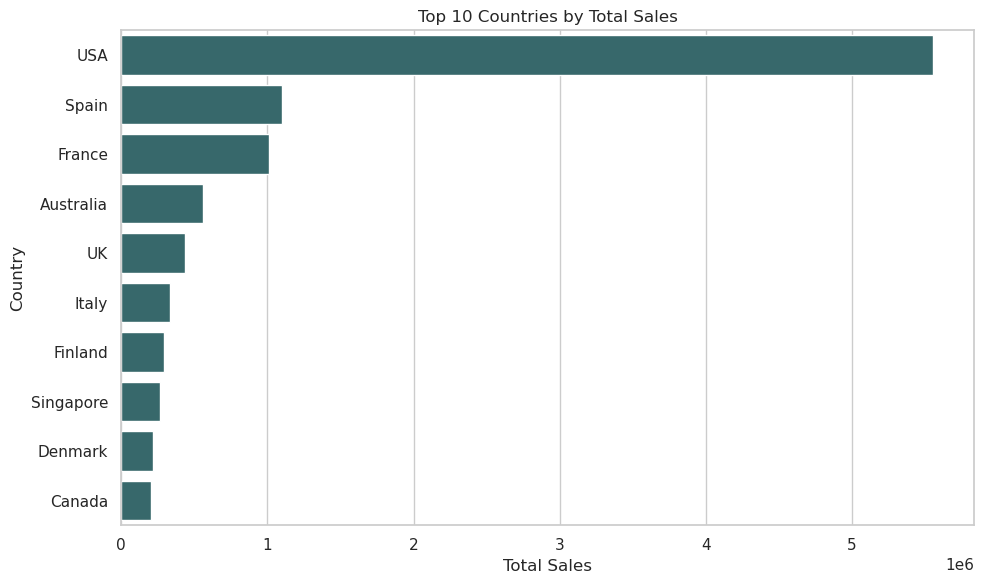

In [5]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=product_sales_by_country_df.sort_values("total_sales", ascending=False).head(10),
    x="total_sales",
    y="country",
    color="#2f6f73",
)
plt.title("Top 10 Countries by Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("Country")
plt.tight_layout()
plt.show()


## Detailed Product Sales Dataset

This combines three analytical tables:

- `fact_orders`
- `dim_products`
- `dim_locations`

The result is the dataset used by the interactive dashboard.


In [6]:
product_sales_df = con.sql(f"""
    SELECT
        f.orderDate AS orderdate,
        p.productLine AS productline,
        p.productName AS productname,
        l.country AS country,
        ROUND(SUM(f.orderAmount), 2) AS total_sales
    FROM read_parquet('{base_path}/fact_orders/*.parquet') f
    JOIN read_parquet('{base_path}/dim_products/*.parquet') p
        ON f.productCode = p.productCode
    JOIN read_parquet('{base_path}/dim_locations/*.parquet') l
        ON f.postalCode = l.postalCode
    GROUP BY 1, 2, 3, 4
    ORDER BY 1, 2, 3, 4
""").df()

product_sales_df["orderdate"] = pd.to_datetime(product_sales_df["orderdate"])
product_sales_df.head()


,orderdate,productline,productname,country,total_sales
0,2003-01-06,Vintage Cars,1911 Ford Town Car,USA,2754.50
1,2003-01-06,Vintage Cars,1917 Grand Touring Sedan,USA,4080.00
2,2003-01-06,Vintage Cars,1932 Alfa Romeo 8C2300 Spider Sport,USA,1660.12
3,2003-01-06,Vintage Cars,1936 Mercedes Benz 500k Roadster,USA,1729.21
4,2003-01-09,Vintage Cars,1928 Mercedes-Benz SSK,Germany,4343.56


## Interactive Dashboard

Use the controls to filter by date range, country, product line, and number of products to display.


In [7]:
country_widget = widgets.Dropdown(
    options=["ALL"] + sorted(product_sales_df["country"].dropna().unique().tolist()),
    value="ALL",
    description="Country",
)

productline_widget = widgets.Dropdown(
    options=["ALL"] + sorted(product_sales_df["productline"].dropna().unique().tolist()),
    value="ALL",
    description="Product Line",
)

@widgets.interact(
    start_date=widgets.DatePicker(value=product_sales_df.orderdate.min().date(), description="Start Date"),
    end_date=widgets.DatePicker(value=product_sales_df.orderdate.max().date(), description="End Date"),
    country=country_widget,
    productline=productline_widget,
    top_n=widgets.IntSlider(value=5, min=1, max=10, step=1, description="Top N"),
)
def plot_top_n_sales(start_date, end_date, country, productline, top_n):
    if start_date is None or end_date is None:
        print("Please select a start and end date.")
        return

    filtered_df = product_sales_df[
        (product_sales_df.orderdate >= pd.Timestamp(start_date))
        & (product_sales_df.orderdate <= pd.Timestamp(end_date))
    ].copy()

    if productline != "ALL":
        filtered_df = filtered_df[filtered_df.productline == productline]

    if country != "ALL":
        filtered_df = filtered_df[filtered_df.country == country]

    if filtered_df.empty:
        print(f"There were no sales for product line '{productline}' in country '{country}' during that period.")
        return

    grouped_df = (
        filtered_df.groupby("productname", as_index=False)["total_sales"]
        .sum()
        .sort_values("total_sales", ascending=False)
        .head(top_n)
    )

    title_parts = [f"Top {top_n} Products"]
    if productline != "ALL":
        title_parts.append(f"in {productline}")
    if country != "ALL":
        title_parts.append(f"for {country}")

    plt.figure(figsize=(10, 6))
    sns.barplot(data=grouped_df, x="total_sales", y="productname", color="#2f6f73")
    plt.title(" ".join(title_parts))
    plt.xlabel("Total Sales")
    plt.ylabel("Product Name")
    plt.tight_layout()
    plt.show()


interactive(children=(DatePicker(value=datetime.date(2003, 1, 6), description='Start Date', step=1), DatePicke…

## What You Just Did

A managed cloud dashboard can use Athena to query Parquet files in S3.

This notebook uses DuckDB to query Parquet files in MinIO.

The learning goal is the same: once operational data is transformed into analytical Parquet files, analysts can query it without hitting the transactional MySQL database.


In [10]:
con.sql(f"""
CREATE OR REPLACE TEMP VIEW order_level AS
SELECT
    orderNumber,
    customerNumber,
    postalCode,
    status,
    MIN(orderDate) AS orderDate,
    MIN(requiredDate) AS requiredDate,
    MIN(shippedDate) AS shippedDate,
    SUM(orderAmount) AS order_value
FROM read_parquet('{base_path}/fact_orders/*.parquet')
GROUP BY
    orderNumber,
    customerNumber,
    postalCode,
    status
""")

In [11]:
df_order_level = con.sql("""
SELECT *
FROM order_level
LIMIT 10
""").df()

df_order_level

,orderNumber,customerNumber,postalCode,status,orderDate,requiredDate,shippedDate,order_value
0,10101,128,60528,Shipped,2003-01-09,2003-01-18,2003-01-11,10549.01
1,10102,181,10022,Shipped,2003-01-10,2003-01-18,2003-01-14,5494.78
2,10106,278,24100,Shipped,2003-02-17,2003-02-24,2003-02-21,52151.81
3,10109,486,71270,Shipped,2003-03-10,2003-03-19,2003-03-11,25833.14
4,10111,129,94217,Shipped,2003-03-25,2003-03-31,2003-03-30,16537.85
5,10112,144,S-958 22,Shipped,2003-03-24,2003-04-03,2003-03-29,7674.94
6,10113,124,97562,Shipped,2003-03-26,2003-04-02,2003-03-27,11044.30
7,10114,172,75012,Shipped,2003-04-01,2003-04-07,2003-04-02,33383.14
8,10116,381,B-6000,Shipped,2003-04-11,2003-04-19,2003-04-13,1627.56
9,10118,216,08022,Shipped,2003-04-21,2003-04-29,2003-04-26,3101.40


In [12]:
query = """
SELECT
    status,
    COUNT(DISTINCT orderNumber) AS total_orders,
    ROUND(SUM(order_value), 2) AS total_revenue
FROM order_level
GROUP BY status
ORDER BY total_orders DESC
"""

df_status = con.sql(query).df()
df_status

,status,total_orders,total_revenue
0,Shipped,303,8865094.64
1,Cancelled,6,238854.18
2,In Process,6,135271.52
3,Resolved,4,134235.88
4,On Hold,4,169575.61
5,Disputed,3,61158.78


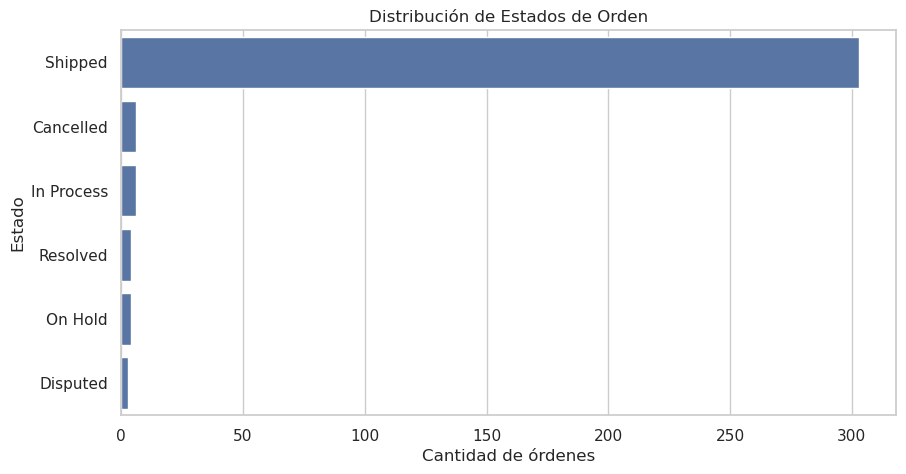

In [13]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=df_status,
    x="total_orders",
    y="status"
)

plt.title("Distribución de Estados de Orden")
plt.xlabel("Cantidad de órdenes")
plt.ylabel("Estado")
plt.show()

In [14]:
query = """
SELECT
    orderNumber,
    status,
    orderDate,
    requiredDate,
    shippedDate,
    DATE_DIFF('day', orderDate, shippedDate) AS days_to_ship,
    DATE_DIFF('day', requiredDate, shippedDate) AS shipping_delay,
    order_value
FROM order_level
WHERE shippedDate IS NOT NULL
"""

df_shipping = con.sql(query).df()
df_shipping.head()

,orderNumber,status,orderDate,requiredDate,shippedDate,days_to_ship,shipping_delay,order_value
0,10101,Shipped,2003-01-09,2003-01-18,2003-01-11,2,-7,10549.01
1,10102,Shipped,2003-01-10,2003-01-18,2003-01-14,4,-4,5494.78
2,10106,Shipped,2003-02-17,2003-02-24,2003-02-21,4,-3,52151.81
3,10109,Shipped,2003-03-10,2003-03-19,2003-03-11,1,-8,25833.14
4,10111,Shipped,2003-03-25,2003-03-31,2003-03-30,5,-1,16537.85


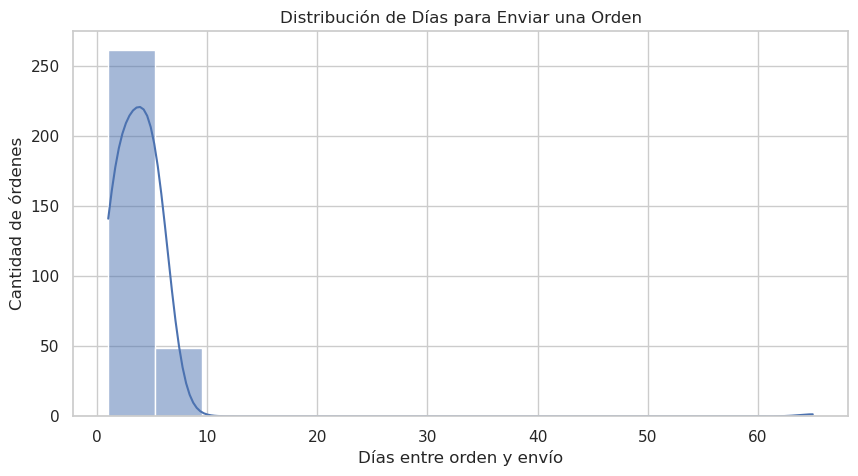

In [15]:
plt.figure(figsize=(10, 5))
sns.histplot(
    data=df_shipping,
    x="days_to_ship",
    bins=15,
    kde=True
)

plt.title("Distribución de Días para Enviar una Orden")
plt.xlabel("Días entre orden y envío")
plt.ylabel("Cantidad de órdenes")
plt.show()

In [16]:
query = f"""
SELECT
    o.orderNumber,
    c.customerName,
    l.country,
    o.requiredDate,
    o.shippedDate,
    DATE_DIFF('day', o.requiredDate, o.shippedDate) AS days_late,
    ROUND(o.order_value, 2) AS order_value
FROM order_level o
JOIN read_parquet('{base_path}/dim_customers/*.parquet') c
    ON o.customerNumber = c.customerNumber
JOIN read_parquet('{base_path}/dim_locations/*.parquet') l
    ON o.postalCode = l.postalCode
WHERE
    o.shippedDate IS NOT NULL
    AND o.shippedDate > o.requiredDate
ORDER BY days_late DESC, order_value DESC
"""

df_late_orders = con.sql(query).df()
df_late_orders

,orderNumber,customerName,country,requiredDate,shippedDate,days_late,order_value
0,10165,"Dragon Souveniers, Ltd.",Singapore,2003-10-31,2003-12-26,56,67392.85


In [17]:
query = f"""
SELECT
    l.country,
    COUNT(DISTINCT o.orderNumber) AS shipped_orders,
    ROUND(AVG(DATE_DIFF('day', o.orderDate, o.shippedDate)), 2) AS avg_days_to_ship,
    ROUND(
        AVG(
            CASE 
                WHEN o.shippedDate > o.requiredDate THEN 1.0 
                ELSE 0.0 
            END
        ) * 100,
        2
    ) AS late_shipping_rate_pct
FROM order_level o
JOIN read_parquet('{base_path}/dim_locations/*.parquet') l
    ON o.postalCode = l.postalCode
WHERE o.shippedDate IS NOT NULL
GROUP BY l.country
HAVING COUNT(DISTINCT o.orderNumber) >= 2
ORDER BY late_shipping_rate_pct DESC, avg_days_to_ship DESC
"""

df_country_delay = con.sql(query).df()
df_country_delay

,country,shipped_orders,avg_days_to_ship,late_shipping_rate_pct
0,Singapore,9,9.11,11.11
1,Japan,6,6.17,0.00
2,Philippines,3,5.33,0.00
3,Ireland,2,4.50,0.00
4,Italy,8,4.38,0.00
5,Sweden,5,4.20,0.00
6,Australia,18,4.06,0.00
7,Spain,34,3.82,0.00
8,Norway,4,3.75,0.00
9,Norway,5,3.60,0.00


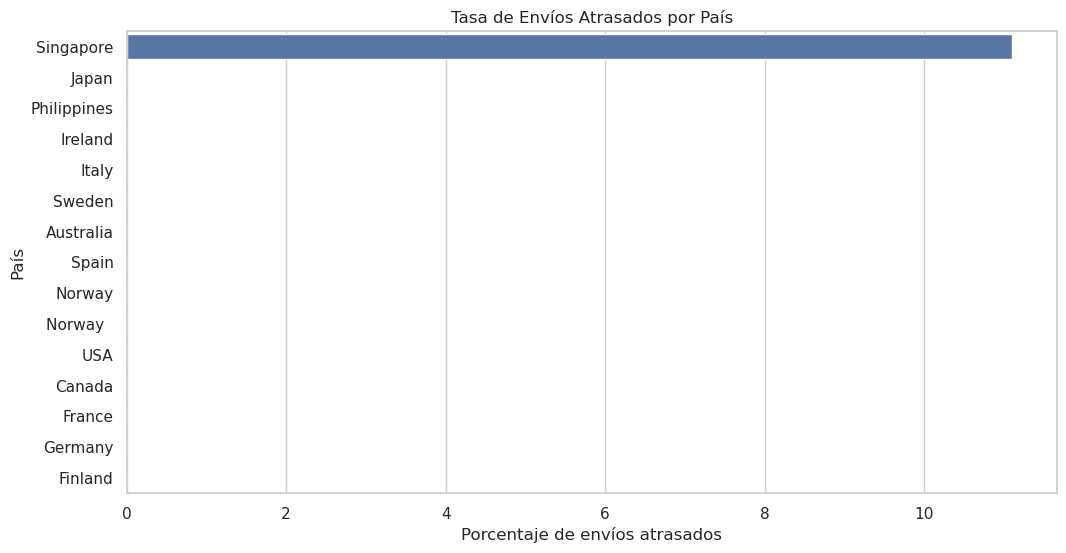

In [18]:
plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_country_delay.head(15),
    x="late_shipping_rate_pct",
    y="country"
)

plt.title("Tasa de Envíos Atrasados por País")
plt.xlabel("Porcentaje de envíos atrasados")
plt.ylabel("País")
plt.show()

In [19]:
query = """
SELECT
    status,
    order_value
FROM order_level
"""

df_order_value_status = con.sql(query).df()
df_order_value_status.head()

,status,order_value
0,Shipped,10549.01
1,Shipped,5494.78
2,Shipped,52151.81
3,Shipped,25833.14
4,Shipped,16537.85


In [20]:
query = """
SELECT
    status,
    order_value
FROM order_level
"""

df_order_value_status = con.sql(query).df()
df_order_value_status.head()

,status,order_value
0,Shipped,10549.01
1,Shipped,5494.78
2,Shipped,52151.81
3,Shipped,25833.14
4,Shipped,16537.85


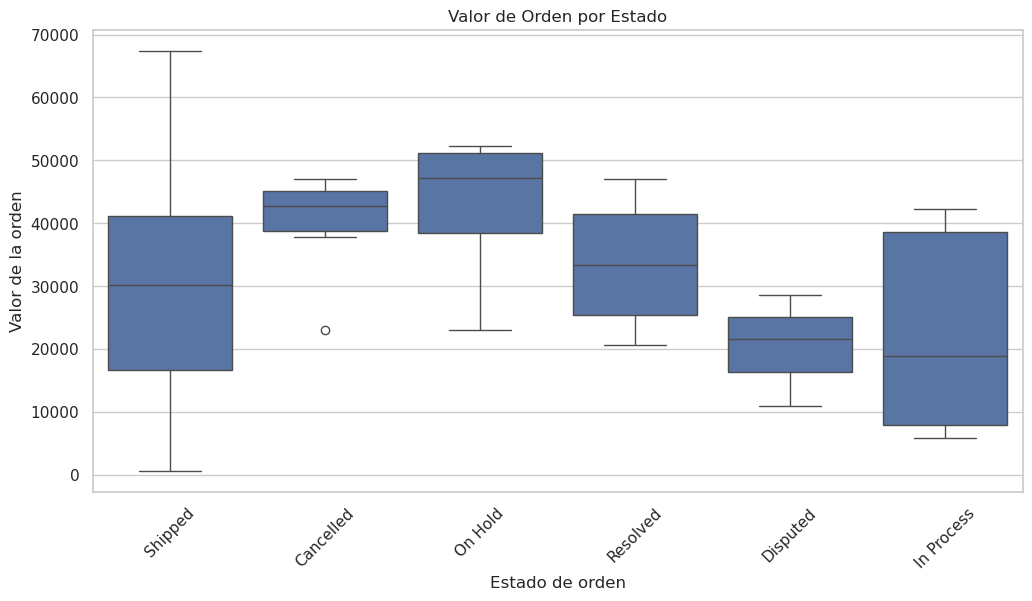

In [21]:
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df_order_value_status,
    x="status",
    y="order_value"
)

plt.title("Valor de Orden por Estado")
plt.xlabel("Estado de orden")
plt.ylabel("Valor de la orden")
plt.xticks(rotation=45)
plt.show()